# The ARIMA Family

Simulated series (where the true orders are known) for AR/MA/ARMA identification, then the bakery daily sales from [EDA.ipynb](EDA.ipynb) for ARIMA, SARIMA and SARIMAX.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

rng = np.random.default_rng(7)
N = 600

def simulate(ar=(), ma=(), n=N, seed=7):
    '''ar/ma given as the coefficients in the model equation (signs as written in the text).'''
    ar_poly = np.r_[1, -np.asarray(ar, float)]     # statsmodels wants 1 - phi_1 B - ...
    ma_poly = np.r_[1,  np.asarray(ma, float)]     # ...and 1 + theta_1 B + ...
    return ArmaProcess(ar_poly, ma_poly).generate_sample(n, distrvs=np.random.default_rng(seed).standard_normal)

def id_plot(x, title, lags=25):
    '''series + ACF + PACF on one row — the identification triplet.'''
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    ax[0].plot(x, lw=0.7); ax[0].set_title(title)
    plot_acf(x, lags=lags, ax=ax[1]);  ax[1].set_title("ACF")
    plot_pacf(x, lags=lags, ax=ax[2], method="ywm"); ax[2].set_title("PACF")
    plt.tight_layout(); plt.show()

## 1. Autoregressive (AR) models

**AR(1) intuition.** Today is a fraction of yesterday, plus a fresh shock:

$$y_t = c + \phi_1 y_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \text{WN}(0,\sigma^2)$$

**General AR(p):**

$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t$$

**Why the past predicts the present:** the series has memory — a shock at time $t$ enters $y_t$, and $y_t$ then feeds into $y_{t+1}$ through $\phi_1$, into $y_{t+2}$ through $\phi_1^2$, and so on. Momentum, decaying geometrically.

**Interpreting the coefficients:**

| $\phi_1$ | Behaviour |
|---|---|
| $0 < \phi_1 < 1$ | smooth, persistent, mean-reverting; larger ⇒ slower reversion |
| $\phi_1 \to 1$ | very slow reversion; at exactly 1 it is a random walk (not stationary) |
| $\phi_1 < 0$ | oscillates — above the mean, then below |

The mean is $\mu = c/(1-\phi_1)$, and a shock retains $\phi_1^h$ of its size after $h$ periods.

**Stationarity.** AR(p) is stationary iff all roots of $1 - \phi_1 B - \cdots - \phi_p B^p = 0$ lie **outside** the unit circle. For AR(1) that reduces to $|\phi_1| < 1$; for AR(2) it is the triangle $\phi_1 + \phi_2 < 1$, $\phi_2 - \phi_1 < 1$, $|\phi_2| < 1$.

**ACF/PACF signature — and how to pick $p$: ACF tails off, PACF cuts off after lag $p$.**

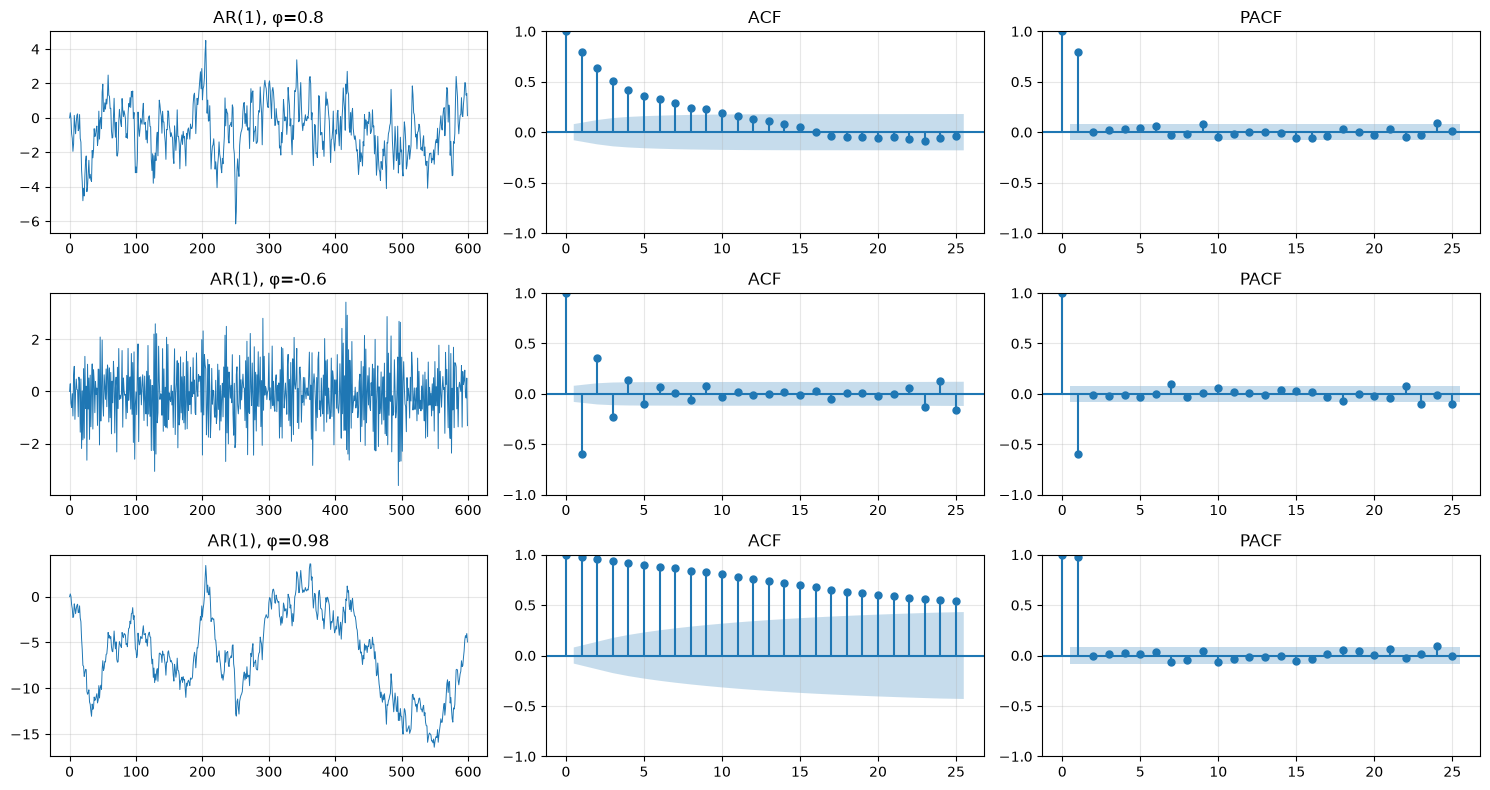

In [2]:
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
for i, phi in enumerate([0.8, -0.6, 0.98]):
    x = simulate(ar=[phi])
    axes[i, 0].plot(x, lw=0.7); axes[i, 0].set_title(f"AR(1), φ={phi}")
    plot_acf(x, lags=25, ax=axes[i, 1]);  axes[i, 1].set_title("ACF")
    plot_pacf(x, lags=25, ax=axes[i, 2], method="ywm"); axes[i, 2].set_title("PACF")
plt.tight_layout(); plt.show()

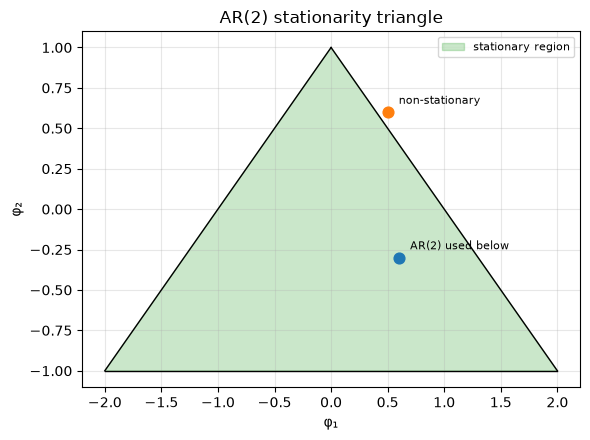

In [3]:
# AR(2) stationarity triangle
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.fill([-2, 2, 0, -2], [-1, -1, 1, -1], alpha=0.25, color="tab:green", label="stationary region")
ax.plot([-2, 2], [-1, -1], "k-", lw=1)
ax.plot([-2, 0], [-1, 1], "k-", lw=1)
ax.plot([2, 0],  [-1, 1], "k-", lw=1)
for p1, p2, lab in [(0.6, -0.3, "AR(2) used below"), (0.5, 0.6, "non-stationary")]:
    ax.scatter([p1], [p2], s=60, zorder=5)
    ax.annotate(lab, (p1, p2), textcoords="offset points", xytext=(8, 6), fontsize=8)
ax.set_xlabel("φ₁"); ax.set_ylabel("φ₂"); ax.set_title("AR(2) stationarity triangle")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

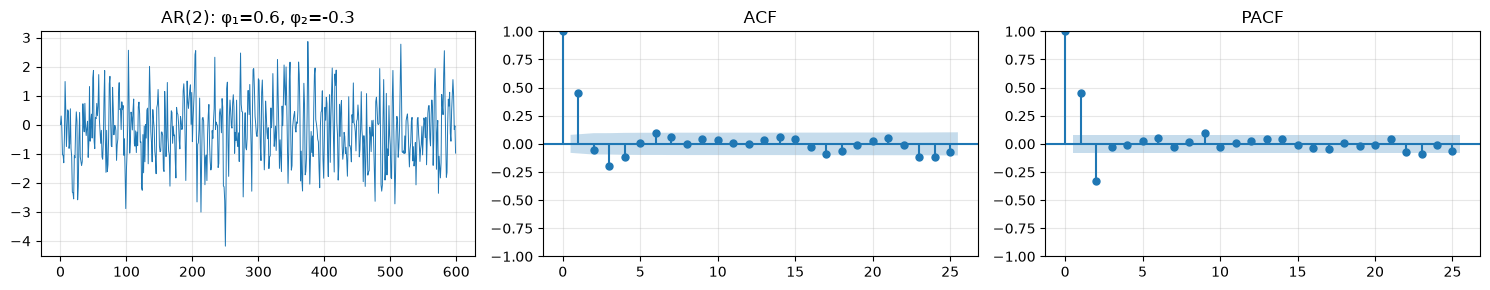

sample PACF (should die after lag 2): [ 0.452 -0.326 -0.025 -0.01   0.024]
theoretical PACF                    : [ 0.462 -0.3    0.    -0.     0.   ]

selecting p by AIC (true p = 2):
   AR(1)  AIC =  1677.36
   AR(2)  AIC =  1612.00
   AR(3)  AIC =  1613.66
   AR(4)  AIC =  1615.58
   AR(5)  AIC =  1617.24


In [4]:
ar2 = simulate(ar=[0.6, -0.3])
id_plot(ar2, "AR(2): φ₁=0.6, φ₂=-0.3")

print("sample PACF (should die after lag 2):", np.round(pacf(ar2, nlags=5, method="ywm")[1:6], 3))
print("theoretical PACF                    :",
      np.round(ArmaProcess(np.r_[1, -np.array([0.6, -0.3])], [1]).pacf(6)[1:6], 3))

print("\nselecting p by AIC (true p = 2):")
for p in range(1, 6):
    print(f"   AR({p})  AIC = {ARIMA(ar2, order=(p, 0, 0)).fit().aic:8.2f}")

PACF cuts off cleanly after lag 2 while the ACF decays — and AIC picks $p=2$. At $\phi = 0.98$ the ACF barely decays over 25 lags: near-unit-root behaviour, visually indistinguishable from non-stationary.

## 2. Moving average (MA) models

**MA(1) intuition.** Today is a fresh shock plus an echo of *yesterday's shock* — not of yesterday's value:

$$y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1}$$

**General MA(q):**

$$y_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1} + \cdots + \theta_q\varepsilon_{t-q}$$

**MA model ≠ moving-average smoothing.** Different objects entirely:

| | MA(q) model | Moving-average smoothing |
|---|---|---|
| Averages | unobserved **shocks** $\varepsilon$ | observed **values** $y$ |
| Purpose | generative model of the data | descriptive smoother |
| Fitted by | MLE | arithmetic |

**Interpreting $\theta$:** a shock affects the series for exactly $q$ periods and then vanishes completely — memory is **finite**, unlike AR's infinite geometric decay. $\theta_1 > 0$ prolongs a shock; $\theta_1 < 0$ reverses it next period.

**Invertibility** (interview level): an MA is invertible when it can be rewritten as an infinite AR with decaying weights, which requires the roots of $1 + \theta_1 B + \cdots + \theta_q B^q$ to lie outside the unit circle ($|\theta_1| < 1$ for MA(1)). Two reasons it matters: (i) $\theta$ and $1/\theta$ produce **identical** ACFs, so without the constraint the model is unidentified; (ii) forecasting needs to recover $\varepsilon_t$ from observed $y$, which only works in the invertible representation.

**ACF/PACF signature — the mirror image of AR: ACF cuts off after lag $q$, PACF tails off.**

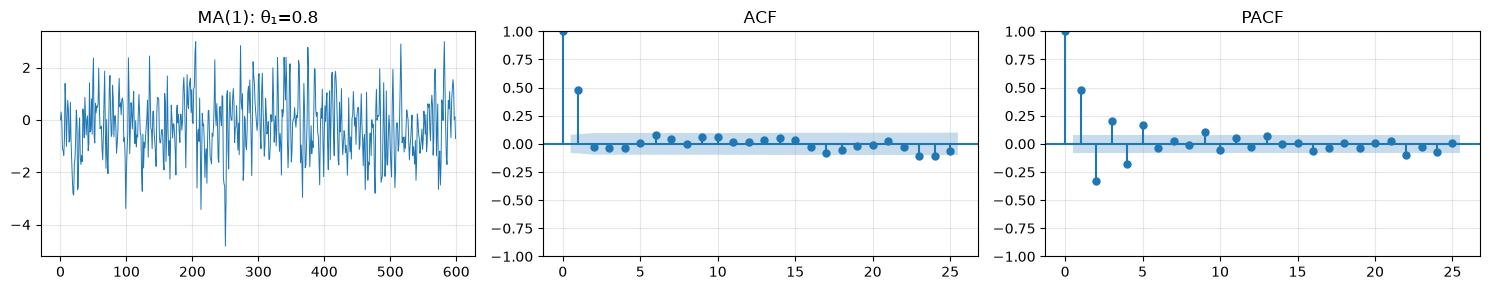

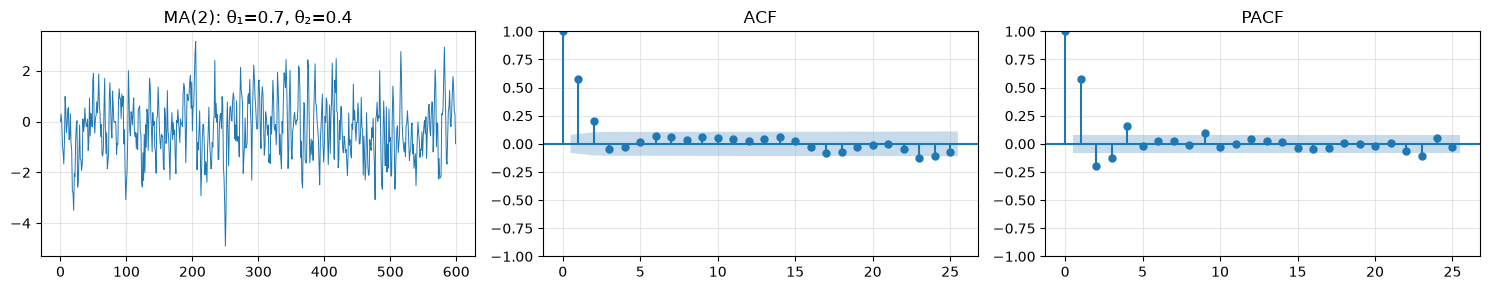

MA(1) θ=0.8:  theoretical ρ₁ = 0.488   sample ρ₁ = 0.475
                sample ρ₂ = -0.032  (≈ 0 — the cut-off)

non-identifiability: θ and 1/θ give the same ACF
   θ=0.5  ρ₁ = 0.4000   invertible: True
   θ=2.0  ρ₁ = 0.4000   invertible: False

selecting q by AIC (true q = 2):
   MA(1)  AIC =  1695.29
   MA(2)  AIC =  1612.50
   MA(3)  AIC =  1614.23
   MA(4)  AIC =  1616.13
   MA(5)  AIC =  1615.29


In [5]:
ma1 = simulate(ma=[0.8])
ma2 = simulate(ma=[0.7, 0.4])
id_plot(ma1, "MA(1): θ₁=0.8")
id_plot(ma2, "MA(2): θ₁=0.7, θ₂=0.4")

# theoretical ACF of MA(1): rho_1 = theta/(1+theta^2), zero beyond
th = 0.8
print(f"MA(1) θ={th}:  theoretical ρ₁ = {th/(1+th**2):.3f}   sample ρ₁ = {acf(ma1, nlags=2)[1]:.3f}")
print(f"                sample ρ₂ = {acf(ma1, nlags=2)[2]:.3f}  (≈ 0 — the cut-off)")

print("\nnon-identifiability: θ and 1/θ give the same ACF")
for t_ in (0.5, 2.0):
    print(f"   θ={t_:3}  ρ₁ = {t_/(1+t_**2):.4f}   invertible: {abs(t_) < 1}")

print("\nselecting q by AIC (true q = 2):")
for q in range(1, 6):
    print(f"   MA({q})  AIC = {ARIMA(ma2, order=(0, 0, q)).fit().aic:8.2f}")

The ACF of MA(1) has one significant spike then nothing; MA(2) has two. The PACF decays instead — exactly the reverse of the AR pattern. Note $\theta=0.5$ and $\theta=2.0$ give identical $\rho_1 = 0.4$: only the invertible one ($|\theta|<1$) is estimable.

## 3. ARMA models

**Why combine.** A pure AR needs many lags to represent a slowly decaying pattern; a pure MA needs many lags to represent persistence. Mixing them describes the same dynamics with far fewer parameters — the **parsimony** argument.

$$y_t = c + \underbrace{\sum_{i=1}^{p}\phi_i y_{t-i}}_{\text{AR: memory of past values}} + \underbrace{\varepsilon_t + \sum_{j=1}^{q}\theta_j \varepsilon_{t-j}}_{\text{MA: memory of past shocks}}$$

The AR part sets how the *level* propagates; the MA part sets how a *surprise* propagates.

| | ACF | PACF |
|---|---|---|
| AR(p) | tails off | **cuts off at $p$** |
| MA(q) | **cuts off at $q$** | tails off |
| ARMA(p,q) | tails off | tails off |

**When ARMA is appropriate:** both ACF and PACF decay rather than cut off — neither pure form fits. Choose orders by AIC/BIC, not by eye, since ARMA has no clean visual signature.

**Why stationarity is required.** The model has a single fixed $c$, $\phi$, $\theta$ and $\sigma^2$. If the mean or variance drifts, no fixed parameter set describes the series, the likelihood is misspecified, and the estimates describe no period in particular. That constraint is what ARIMA relaxes.

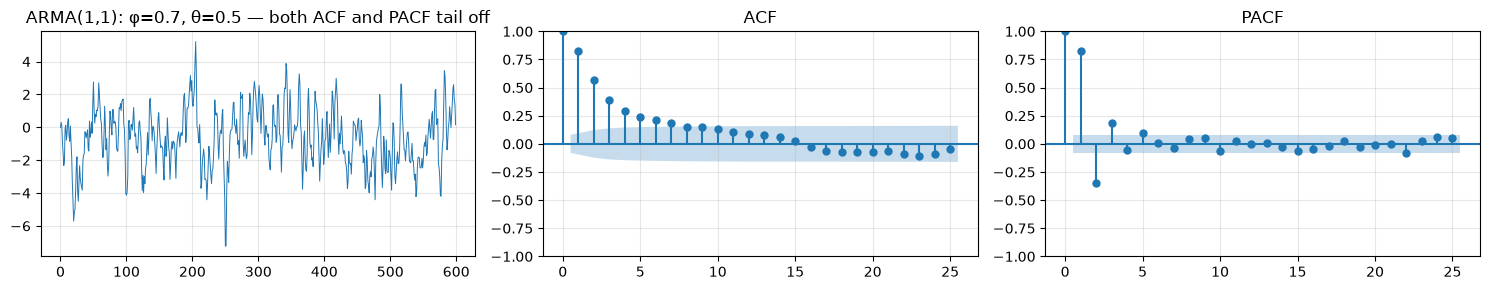

AIC over a small grid (true order = (1,1)):
        q=0     q=1     q=2
p=0  2390.7  1865.3  1693.2
p=1  1714.6  1613.6  1615.6
p=2  1638.9  1615.6  1617.5

best: (1, 1)


In [6]:
arma11 = simulate(ar=[0.7], ma=[0.5])
id_plot(arma11, "ARMA(1,1): φ=0.7, θ=0.5 — both ACF and PACF tail off")

print("AIC over a small grid (true order = (1,1)):")
grid = {}
for p in range(3):
    for q in range(3):
        try:
            grid[(p, q)] = ARIMA(arma11, order=(p, 0, q)).fit().aic
        except Exception:
            grid[(p, q)] = np.nan
tbl = pd.DataFrame(
    [[round(grid[(p, q)], 1) for q in range(3)] for p in range(3)],
    index=[f"p={p}" for p in range(3)], columns=[f"q={q}" for q in range(3)])
print(tbl)
print("\nbest:", min(grid, key=grid.get))

## 4. ARIMA models

**Why ARMA cannot take a non-stationary series.** ARMA assumes a constant mean and variance. Fit it to a trending series and $\hat\phi_1 \to 1$, standard errors are invalid, and forecasts drift arbitrarily.

**Role of differencing.** Replace the series with its changes, which removes the trend:

$$\Delta y_t = y_t - y_{t-1}, \qquad \Delta^d y_t = (1-B)^d y_t$$

**ARIMA(p,d,q)** is exactly "difference $d$ times, then fit ARMA(p,q)":

$$\phi_p(B)\,(1-B)^d y_t = c + \theta_q(B)\,\varepsilon_t$$

| Term | Meaning | Chosen by |
|---|---|---|
| $p$ | AR lags — persistence of the level | PACF cut-off, AIC |
| $d$ | differences needed for stationarity | ADF/KPSS on the differenced series |
| $q$ | MA lags — persistence of shocks | ACF cut-off, AIC |

ARIMA$(p,0,q)$ **is** ARMA$(p,q)$; ARIMA(0,1,0) is a random walk; ARIMA(0,1,1) is exponential smoothing.

**Choosing $d$ without over-differencing.** Take the smallest $d$ that passes a stationarity test. The tell-tale signs of going too far: the **variance rises** rather than falls, and the lag-1 autocorrelation of the differenced series goes strongly negative (≈ −0.5), which is a spurious MA(1) you then have to model away.

series    ADF p   std  acf(1)
     y    0.047 153.8   0.777
    Δy 6.62e-07 102.7  -0.160
   Δ²y 1.62e-18 156.6  -0.511
   Δ₇y 9.44e-08 101.7   0.636
  ΔΔ₇y 3.09e-14  86.9  -0.268


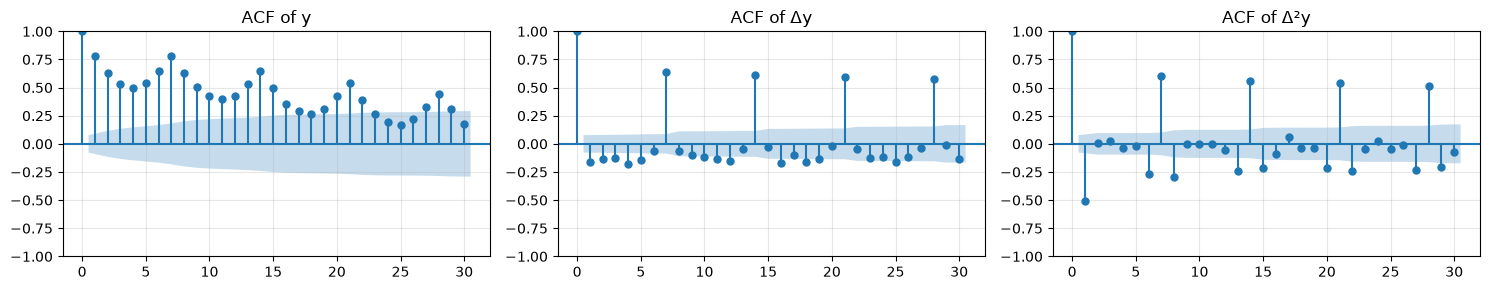

In [7]:
bakery = pd.read_csv("../data/daily_sales_french_bakery.csv", parse_dates=["ds"])
y = (bakery[bakery["unique_id"] == "TRADITIONAL BAGUETTE"]
     .sort_values("ds").set_index("ds")["y"].asfreq("D"))

rows = []
for lab, z in [("y", y), ("Δy", y.diff()), ("Δ²y", y.diff().diff()),
               ("Δ₇y", y.diff(7)), ("ΔΔ₇y", y.diff(7).diff())]:
    z = z.dropna()
    rows.append({"series": lab, "ADF p": f"{adfuller(z, autolag='AIC')[1]:.3g}",
                 "std": round(z.std(), 1), "acf(1)": round(acf(z, nlags=1)[1], 3)})
print(pd.DataFrame(rows).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, (lab, z) in zip(axes, [("y", y), ("Δy", y.diff()), ("Δ²y", y.diff().diff())]):
    plot_acf(z.dropna(), lags=30, ax=ax); ax.set_title(f"ACF of {lab}")
plt.tight_layout(); plt.show()

$d=1$ drops the std from 153.8 to 102.7 and the ADF p-value to 6.6e-07. $d=2$ pushes the std back up to 156.6 with acf(1) = −0.51 — the classic over-differencing signature, so stop at $d=1$.

The ACF of $\Delta y$ still shows spikes at 7, 14, 21: **ordinary differencing removed the trend but not the season.**

## 5. Seasonal ARIMA (SARIMA)

**Why ordinary ARIMA is not enough.** To reach lag 7 with non-seasonal terms you would need $p \ge 7$ — seven parameters to express one weekly effect, and the ACF above shows the pattern survives differencing anyway.

SARIMA adds a second set of terms operating at the seasonal lag $m$:

$$\underbrace{\Phi_P(B^m)\,\phi_p(B)}_{\text{AR}}\ \underbrace{(1-B^m)^D (1-B)^d}_{\text{differencing}}\ y_t = \underbrace{\Theta_Q(B^m)\,\theta_q(B)}_{\text{MA}}\ \varepsilon_t$$

written **SARIMA$(p,d,q)(P,D,Q)_m$**.

| Term | Meaning |
|---|---|
| $P$ | seasonal AR — this Monday depends on last Monday |
| $D$ | seasonal differences, $y_t - y_{t-m}$ |
| $Q$ | seasonal MA — echo of the shock $m$ periods ago |
| $m$ | season length: 7 daily/weekly, 12 monthly, 4 quarterly |

**Ordinary vs seasonal differencing** solve different problems: $\Delta$ removes trend, $\Delta_m$ removes the repeating pattern *and* any constant level. Apply the **seasonal difference first**, then check whether $d=1$ is still needed. Rarely go beyond $D=1$.

**Reading seasonal ACF/PACF:** look only at lags $m, 2m, 3m$. A spike at lag $m$ in the PACF that dies afterwards ⇒ $P=1$; a spike at lag $m$ in the ACF that dies ⇒ $Q=1$.

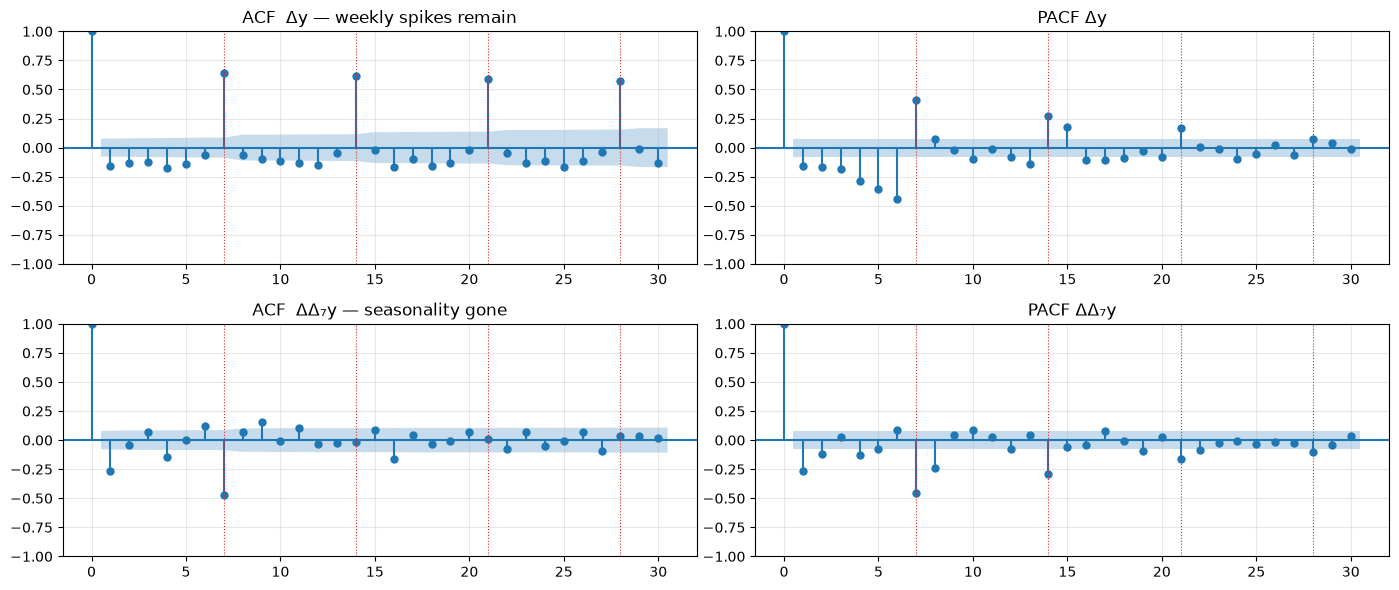

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
plot_acf(y.diff().dropna(),           lags=30, ax=axes[0, 0]); axes[0, 0].set_title("ACF  Δy — weekly spikes remain")
plot_pacf(y.diff().dropna(),          lags=30, ax=axes[0, 1], method="ywm"); axes[0, 1].set_title("PACF Δy")
plot_acf(y.diff(7).diff().dropna(),   lags=30, ax=axes[1, 0]); axes[1, 0].set_title("ACF  ΔΔ₇y — seasonality gone")
plot_pacf(y.diff(7).diff().dropna(),  lags=30, ax=axes[1, 1], method="ywm"); axes[1, 1].set_title("PACF ΔΔ₇y")
for a in axes.ravel():
    for L in (7, 14, 21, 28):
        a.axvline(L, color="tab:red", ls=":", lw=0.8)
plt.tight_layout(); plt.show()

In [9]:
log_y = np.log(y.where(y > 0)).interpolate()
H = 28
tr, te = log_y[:-H], log_y[-H:]

specs = [("ARIMA(1,1,1)",           (1, 1, 1), (0, 0, 0, 0)),
         ("ARIMA(2,1,2)",           (2, 1, 2), (0, 0, 0, 0)),
         ("SARIMA(1,1,1)(1,1,1)₇",  (1, 1, 1), (1, 1, 1, 7))]

out = []
fits = {}
for name, order, sorder in specs:
    m = SARIMAX(tr, order=order, seasonal_order=sorder,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    f = m.forecast(H)
    e = te.values - f.values
    fits[name] = m
    out.append({"model": name, "AIC": round(m.aic, 1),
                "MAE (log)": round(np.abs(e).mean(), 4),
                "Ljung-Box p": round(acorr_ljungbox(m.resid[14:], lags=[14],
                                                    return_df=True)["lb_pvalue"].iloc[0], 4)})
pd.DataFrame(out)

,model,AIC,MAE (log),Ljung-Box p
0,"ARIMA(1,1,1)",387.4,0.4668,0.0000
1,"ARIMA(2,1,2)",328.5,0.3128,0.0000
2,"SARIMA(1,1,1)(1,1,1)₇",-40.0,0.1521,0.7785


Adding the seasonal terms takes AIC from 387 to **−40** and the Ljung-Box p-value from 0.0000 to **0.78** — the non-seasonal models leave the weekly pattern sitting in their residuals. Extra non-seasonal lags (2,1,2) help a little but cannot substitute for a seasonal term.

## 6. SARIMAX — adding exogenous variables

**Why.** Some drivers are external and *known*: holidays, promotions, price, weather forecasts, opening hours. SARIMA can only extrapolate the series' own history.

**Formulation — regression with SARIMA errors:**

$$y_t = \beta^\top x_t + n_t, \qquad n_t \sim \text{SARIMA}(p,d,q)(P,D,Q)_m$$

The regression explains what $x_t$ explains; the SARIMA part models whatever structure is left in the residual $n_t$. This is *not* the same as ordinary regression, which would assume independent errors and produce badly understated standard errors.

**Interpreting $\beta$:** the effect of $x_t$ on $y_t$ **holding the ARIMA dynamics constant** — the part of the movement not already predictable from the series' own past.

**Contemporaneous vs lagged.** Use $x_t$ when the effect is immediate (a closure today cuts today's sales); use $x_{t-k}$ when it is delayed (an ad campaign lifting sales a week later). Lagged regressors have a practical advantage: $x_{t-k}$ is already known at time $t$.

**The forecasting catch: you need $x_{T+h}$.** Any exogenous variable must be known or itself forecast over the whole horizon — and forecasting $x$ injects its own error. Calendar-derived regressors (holidays, closures, day-of-week) are the safe case because they are known indefinitely.

**Example.** The bakery closes ~29 Wednesdays a year. That is a *calendar* fact, known in advance, and invisible to SARIMA — which sees only an unexplained drop. Model on the raw scale so the zeros are real.

In [10]:
X = pd.DataFrame({"is_closed": (y == 0).astype(float)}, index=y.index)

tr_r, te_r = y[:-H], y[-H:]
x_tr, x_te = X[:-H], X[-H:]

kw = dict(order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
          enforce_stationarity=False, enforce_invertibility=False)

sarima  = SARIMAX(tr_r, **kw).fit(disp=False)
sarimax = SARIMAX(tr_r, exog=x_tr, **kw).fit(disp=False)

f_sarima  = sarima.forecast(H)
f_sarimax = sarimax.forecast(H, exog=x_te)       # future X must be supplied

comp = []
for name, m, f in [("SARIMA", sarima, f_sarima), ("SARIMAX + is_closed", sarimax, f_sarimax)]:
    e = te_r.values - f.values
    comp.append({"model": name, "AIC": round(m.aic, 1),
                 "MAE": round(np.abs(e).mean(), 2), "RMSE": round(np.sqrt((e ** 2).mean()), 2),
                 "Ljung-Box p": round(acorr_ljungbox(m.resid[14:], lags=[14],
                                                     return_df=True)["lb_pvalue"].iloc[0], 4)})
print(pd.DataFrame(comp).to_string(index=False))
print()
print(sarimax.summary().tables[1])

              model    AIC   MAE  RMSE  Ljung-Box p
             SARIMA 6653.0 80.54 98.46       0.0020
SARIMAX + is_closed 6531.4 35.74 45.79       0.1599

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_closed   -146.9357      9.699    -15.149      0.000    -165.946    -127.925
ar.L1          0.4123      0.060      6.825      0.000       0.294       0.531
ma.L1         -0.7176      0.047    -15.272      0.000      -0.810      -0.626
ar.S.L7        0.0427      0.051      0.841      0.400      -0.057       0.142
ma.S.L7       -0.8578      0.029    -29.458      0.000      -0.915      -0.801
sigma2      3516.8897    116.242     30.255      0.000    3289.059    3744.720


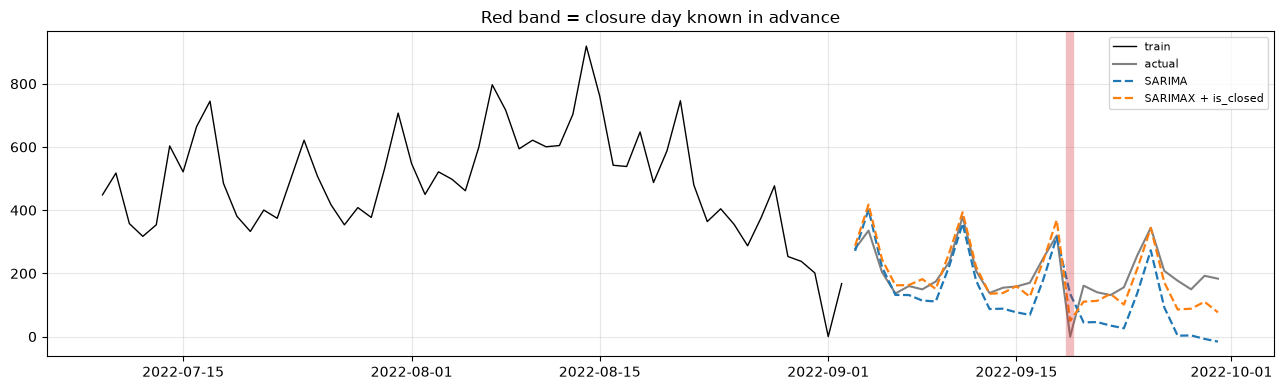

In [11]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(tr_r.index[-56:], tr_r.values[-56:], lw=1, color="black", label="train")
ax.plot(te_r.index, te_r.values, lw=1.5, color="grey", label="actual")
ax.plot(te_r.index, f_sarima.values,  lw=1.6, ls="--", label="SARIMA")
ax.plot(te_r.index, f_sarimax.values, lw=1.6, ls="--", label="SARIMAX + is_closed")
for d_ in te_r.index[x_te["is_closed"] == 1]:
    ax.axvline(d_, color="tab:red", alpha=0.3, lw=6)
ax.set_title("Red band = closure day known in advance")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

**$\hat\beta_{\text{is\_closed}} = -146.9$** (se 9.7, $z = -15.1$): a closure day sells ~147 units fewer than the ARIMA dynamics alone would predict. MAE falls from **80.5 to 35.7** — a 56% improvement — and the residuals go from failing Ljung-Box (p = 0.002) to passing it (p = 0.16).

The gain is possible only because `is_closed` is a **calendar** variable. Had the regressor been tomorrow's weather, forecasting it would have added error of its own.

## 7. ARIMA forecasting

**One-step-ahead.** Every term on the right is known:

$$\hat{y}_{T+1|T} = c + \phi_1 y_T + \cdots + \phi_p y_{T+1-p} + \theta_1 \varepsilon_T + \cdots$$

**Multi-step and recursion.** For $h > 1$ the required $y_{T+1}$ does not exist yet, so the model **feeds its own forecast back in**:

$$\hat{y}_{T+h|T} = c + \sum_{i=1}^{p}\phi_i\, \hat{y}_{T+h-i|T} + \sum_{j\ge h}\theta_j\,\varepsilon_{T+h-j}$$

with unknown future shocks set to their expectation, zero. Two consequences: the MA part contributes nothing beyond lag $q$, and errors compound as forecasts are built on forecasts.

**Behaviour as $h$ grows** — determined entirely by $d$:

| Model | Long-horizon forecast |
|---|---|
| ARMA ($d=0$) | converges to the mean $\mu$, geometrically as $\phi^h$ |
| ARIMA $d=1$ | flattens to a constant (the last level) |
| ARIMA $d=1$ with drift | approaches a straight line |
| ARIMA $d=2$ | approaches a line with slope |

**Forecasting the original series.** Forecasts from a differenced model are forecasts *of the differences*, so they must be integrated back: $\hat{y}_{T+h} = y_T + \sum_{i=1}^{h}\Delta\hat{y}_{T+i}$. `statsmodels` does this automatically when $d$ is part of the order — which is why you should pass $d$ rather than differencing by hand.

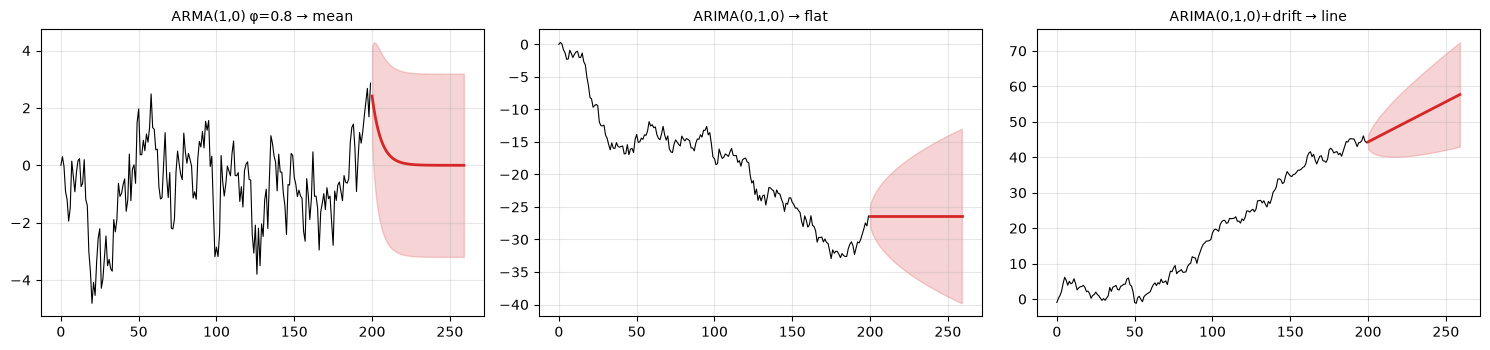

AR(1) φ=0.8 recursion — each forecast feeds the next:
   h=1: ŷ =  2.400   (closed form μ+φ^h(y_T-μ) =  2.400)
   h=2: ŷ =  1.920   (closed form μ+φ^h(y_T-μ) =  1.920)
   h=3: ŷ =  1.536   (closed form μ+φ^h(y_T-μ) =  1.536)
   h=4: ŷ =  1.229   (closed form μ+φ^h(y_T-μ) =  1.229)
   h=5: ŷ =  0.983   (closed form μ+φ^h(y_T-μ) =  0.983)
   h=6: ŷ =  0.786   (closed form μ+φ^h(y_T-μ) =  0.786)


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))

demo = [("ARMA(1,0) φ=0.8 → mean", simulate(ar=[0.8], n=200), (1, 0, 0)),
        ("ARIMA(0,1,0) → flat",    np.cumsum(rng.normal(size=200)), (0, 1, 0)),
        ("ARIMA(0,1,0)+drift → line", np.cumsum(0.3 + rng.normal(size=200)), (0, 1, 0))]

for ax, (title, x, order) in zip(axes, demo):
    trend = "t" if "drift" in title else "n"
    m = ARIMA(x, order=order, trend=trend).fit()
    r = m.get_forecast(60)
    ci = r.conf_int()
    fh = np.arange(len(x), len(x) + 60)
    ax.plot(x, lw=0.8, color="black")
    ax.plot(fh, r.predicted_mean, lw=2, color="tab:red")
    ax.fill_between(fh, ci[:, 0], ci[:, 1], alpha=0.2, color="tab:red")
    ax.set_title(title, fontsize=10)
plt.tight_layout(); plt.show()

# recursion made explicit for AR(1)
phi, y_T, mu = 0.8, 3.0, 0.0
print("AR(1) φ=0.8 recursion — each forecast feeds the next:")
prev = y_T
for h in range(1, 7):
    prev = mu + phi * prev
    print(f"   h={h}: ŷ = {prev:6.3f}   (closed form μ+φ^h(y_T-μ) = {mu + phi**h * (y_T - mu):6.3f})")

## 8. Forecast intervals and uncertainty

A **point forecast** is the conditional mean — a single number that will essentially never be exactly right. A **prediction interval** states a range and a probability:

$$\hat{y}_{T+h|T} \pm z_{\alpha/2}\, \sigma_h$$

**Why uncertainty grows with $h$.** Write the model in MA($\infty$) form, $y_t = \sum_{j\ge0}\psi_j \varepsilon_{t-j}$. The $h$-step forecast error is the sum of all shocks that arrive between $T$ and $T+h$:

$$\sigma_h^2 = \sigma^2 \sum_{j=0}^{h-1} \psi_j^2$$

Each extra step adds another non-negative term, so $\sigma_h$ is **non-decreasing in $h$** — it can never shrink. The shape depends on $d$:

- **Stationary ARMA:** $\psi_j \to 0$ geometrically, so $\sigma_h$ converges to the unconditional standard deviation. The band widens then **plateaus**.
- **$d = 1$:** $\psi_j \to 1$, so $\sigma_h^2 \approx h\sigma^2$ and the band widens like $\sqrt{h}$, without bound.

**Interpreting them in practice.** An 80% interval should contain the truth 80% of the time — verify that by backtesting rather than trusting the formula. Three standard caveats:

- The interval assumes the fitted model is **correct** and ignores parameter-estimation error, which usually makes it too narrow.
- It assumes **Gaussian** errors, which fails on fat-tailed data.
- On a **non-negative** series the band will happily extend below zero.

Miscalibration runs in both directions, so measure it. The check below does exactly that.

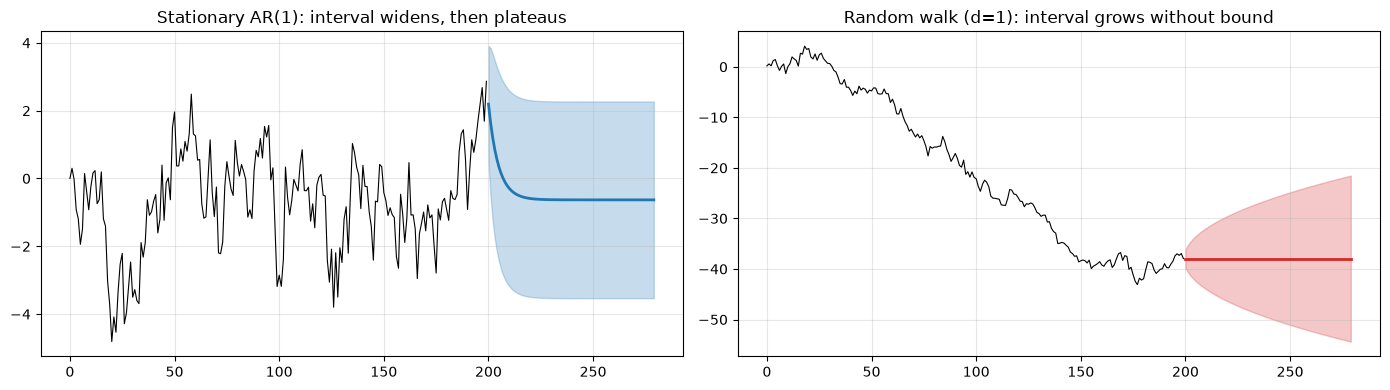

AR(1)  interval width  h=1:   3.42   h=20:   5.80   h=80:   5.80
d=1    interval width  h=1:   3.67   h=20:  16.42   h=80:  32.84
       ratio vs √h        : 8.94 vs √80 = 8.94


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# stationary: band plateaus
x_s = simulate(ar=[0.8], n=200)
r_s = ARIMA(x_s, order=(1, 0, 0)).fit().get_forecast(80)
ci_s = r_s.conf_int(); fh = np.arange(200, 280)
axes[0].plot(x_s, lw=0.8, color="black")
axes[0].plot(fh, r_s.predicted_mean, lw=2, color="tab:blue")
axes[0].fill_between(fh, ci_s[:, 0], ci_s[:, 1], alpha=0.25, color="tab:blue")
axes[0].set_title("Stationary AR(1): interval widens, then plateaus")

# d=1: band grows like sqrt(h)
x_d = np.cumsum(rng.normal(size=200))
r_d = ARIMA(x_d, order=(0, 1, 0)).fit().get_forecast(80)
ci_d = r_d.conf_int()
axes[1].plot(x_d, lw=0.8, color="black")
axes[1].plot(fh, r_d.predicted_mean, lw=2, color="tab:red")
axes[1].fill_between(fh, ci_d[:, 0], ci_d[:, 1], alpha=0.25, color="tab:red")
axes[1].set_title("Random walk (d=1): interval grows without bound")
plt.tight_layout(); plt.show()

w_s = ci_s[:, 1] - ci_s[:, 0]
w_d = ci_d[:, 1] - ci_d[:, 0]
print(f"AR(1)  interval width  h=1: {w_s[0]:6.2f}   h=20: {w_s[19]:6.2f}   h=80: {w_s[79]:6.2f}")
print(f"d=1    interval width  h=1: {w_d[0]:6.2f}   h=20: {w_d[19]:6.2f}   h=80: {w_d[79]:6.2f}")
print(f"       ratio vs √h        : {w_d[79]/w_d[0]:.2f} vs √80 = {np.sqrt(80):.2f}")

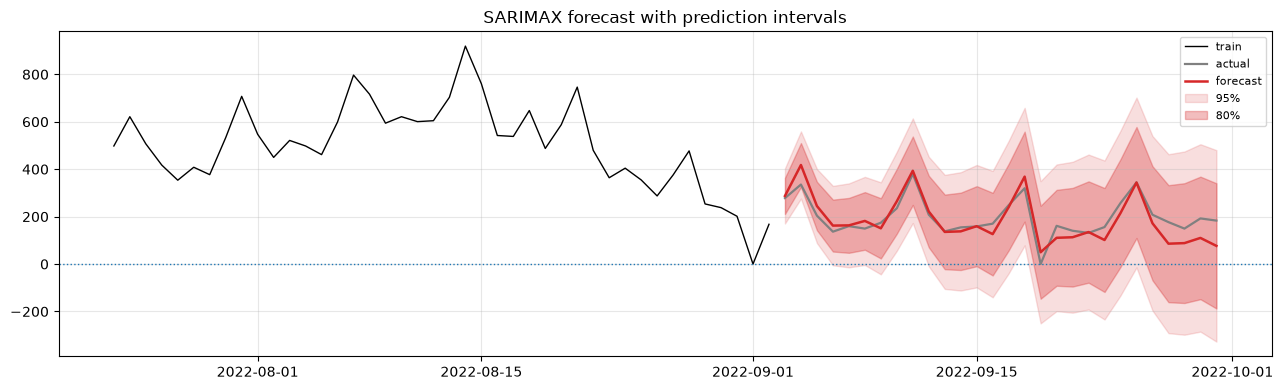

actual coverage — 80% band: 100%   95% band: 100%   (n = 28)
interval width   h=1: 152.0   h=28: 528.0
lower 95% bound goes negative on 22 of 28 days — impossible for a non-negative count


In [14]:
# real data: 80% and 95% bands, and how often the truth lands inside
res = sarimax.get_forecast(H, exog=x_te)
lo80, hi80 = res.conf_int(alpha=0.20).T.values
lo95, hi95 = res.conf_int(alpha=0.05).T.values

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(tr_r.index[-42:], tr_r.values[-42:], lw=1, color="black", label="train")
ax.plot(te_r.index, te_r.values, lw=1.6, color="grey", label="actual")
ax.plot(te_r.index, res.predicted_mean.values, lw=1.8, color="tab:red", label="forecast")
ax.fill_between(te_r.index, lo95, hi95, alpha=0.15, color="tab:red", label="95%")
ax.fill_between(te_r.index, lo80, hi80, alpha=0.30, color="tab:red", label="80%")
ax.axhline(0, color="tab:blue", lw=1, ls=":")
ax.legend(fontsize=8); ax.set_title("SARIMAX forecast with prediction intervals")
plt.tight_layout(); plt.show()

inside80 = ((te_r.values >= lo80) & (te_r.values <= hi80)).mean()
inside95 = ((te_r.values >= lo95) & (te_r.values <= hi95)).mean()
print(f"actual coverage — 80% band: {inside80:.0%}   95% band: {inside95:.0%}   (n = {H})")
print(f"interval width   h=1: {hi80[0]-lo80[0]:.1f}   h={H}: {hi80[-1]-lo80[-1]:.1f}")
print(f"lower 95% bound goes negative on {int((lo95 < 0).sum())} of {H} days "
      f"— impossible for a non-negative count")

Both failure modes show up at once, in opposite directions:

- **The bands are too wide, not too narrow.** The 80% interval covers **100%** of the 28 test days (expected: ~80%). $\sigma^2$ is inflated by the closure days — huge one-off drops the model treats as ordinary noise — so every band is padded for a shock that only occurs on known Wednesdays.
- **The bands are also impossible.** The lower 95% bound falls below zero on **22 of 28 days**, for a quantity that cannot be negative.

Both trace to the same cause: a symmetric Gaussian interval on a skewed, non-negative, spiky series. The fixes are the usual ones — model on the log scale, or use empirical/bootstrapped quantiles instead of $\pm z\sigma_h$. Note also that $n=28$ is far too small to estimate coverage precisely; it is a smoke test, not a calibration study.